# Classification Laboratory

Compare Logistic Regression, KNN, SVM, Decision Tree and Random Forest
on an imbalanced dataset.

Dataset: Adult Income (~48k rows, mixed numeric and categorical)
Target: does this person earn more than $50k?

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             RocCurveDisplay)

RANDOM_STATE = 42

In [4]:
data = fetch_openml("adult", version=2, as_frame=True)
X = data.data
y = (data.target == ">50K").astype(int)

print(X.shape)
print(y.value_counts(normalize=True))
X.head()

(48842, 14)
class
0    0.760718
1    0.239282
Name: proportion, dtype: float64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

In [7]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat_cols)
])

In [9]:
def evaluate(name, classifier):
    """Fit on train, score on validation, return a dict."""
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])
    
    pipeline.fit(X_train, y_train)
    
    preds = pipeline.predict(X_val)
    probs = pipeline.predict_proba(X_val)[:, 1]
    
    result = {
        "model": name,
        "accuracy": accuracy_score(y_val, preds),
        "precision": precision_score(y_val, preds),
        "recall": recall_score(y_val, preds),
        "f1": f1_score(y_val, preds),
        "roc_auc": roc_auc_score(y_val, probs)
    }
    
    return result, pipeline

In [10]:
results = []
fitted = {}

In [25]:
models = {
    "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

In [26]:
for name, model in models.items():
    result, fitted_model = evaluate(name, model)
    
    results.append(result)
    fitted[name] = fitted_model

/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
pd.DataFrame(results).sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
1,Logistic Regression,0.851571,0.732321,0.598203,0.658502,0.907275
4,Random Forest,0.853926,0.726368,0.624733,0.671728,0.906110
2,KNN (k=5),0.833965,0.673459,0.593924,0.631196,0.860507
3,Decision Tree,0.812673,0.602923,0.635430,0.618750,0.751918
0,Baseline (most frequent),0.760774,0.000000,0.000000,0.000000,0.500000


In [14]:
svm_indices = X_train.sample(
    n=5000,
    random_state=RANDOM_STATE
).index

X_train_svm = X_train.loc[svm_indices]
y_train_svm = y_train.loc[svm_indices]

In [15]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=RANDOM_STATE))
])

svm_pipeline.fit(X_train_svm, y_train_svm)

svm_preds = svm_pipeline.predict(X_val)
svm_probs = svm_pipeline.predict_proba(X_val)[:, 1]

svm_result = {
    "model": "SVM (5k train sample)",
    "accuracy": accuracy_score(y_val, svm_preds),
    "precision": precision_score(y_val, svm_preds),
    "recall": recall_score(y_val, svm_preds),
    "f1": f1_score(y_val, svm_preds),
    "roc_auc": roc_auc_score(y_val, svm_probs)
}

results.append(svm_result)
fitted["SVM (5k train sample)"] = svm_pipeline

/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [18]:
pd.DataFrame(results).sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
1,Logistic Regression,0.851571,0.732321,0.598203,0.658502,0.907275
4,Random Forest,0.853926,0.726368,0.624733,0.671728,0.906110
5,SVM (5k train sample),0.854233,0.749045,0.587505,0.658513,0.896397
2,KNN (k=5),0.833965,0.673459,0.593924,0.631196,0.860507
3,Decision Tree,0.812673,0.602923,0.635430,0.618750,0.751918
0,Baseline (most frequent),0.760774,0.000000,0.000000,0.000000,0.500000


In [19]:
baseline = fitted["Baseline (most frequent)"]

baseline_preds = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, baseline_preds))
print("Baseline precision:", precision_score(y_val, baseline_preds))
print("Baseline recall:", recall_score(y_val, baseline_preds))
print("Baseline F1:", f1_score(y_val, baseline_preds))

Baseline accuracy: 0.7607738765482649
Baseline precision: 0.0
Baseline recall: 0.0
Baseline F1: 0.0


/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## The accuracy trap

The baseline achieves approximately 76% accuracy simply by predicting
the majority class for every observation. However, it has zero recall,
precision and F1 because it never predicts the positive class.

This demonstrates why accuracy alone is misleading for an imbalanced
classification problem. A model can achieve high accuracy while
completely failing to identify the minority class.

In [27]:
rf_pipeline = fitted["Random Forest"]

X_val_transformed = rf_pipeline.named_steps["preprocessor"].transform(X_val)

print("Transformed X_val shape:", X_val_transformed.shape)
print("RF expected features:",
      rf_pipeline.named_steps["classifier"].n_features_in_)

Transformed X_val shape: (9769, 105)
RF expected features: 105


In [28]:
rf_preds = fitted["Random Forest"].predict(X_val)

cm = confusion_matrix(y_val, rf_preds)

print(cm)

[[6882  550]
 [ 877 1460]]


In [29]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

True Negatives:  6882
False Positives: 550
False Negatives: 877
True Positives:  1460


In [30]:
probs = fitted["Random Forest"].predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (probs >= t).astype(int)
    
    print(
        f"threshold={t}  "
        f"precision={precision_score(y_val, preds):.3f}  "
        f"recall={recall_score(y_val, preds):.3f}  "
        f"f1={f1_score(y_val, preds):.3f}"
    )

threshold=0.3  precision=0.613  recall=0.793  f1=0.692
threshold=0.4  precision=0.672  recall=0.707  f1=0.689
threshold=0.5  precision=0.722  recall=0.628  f1=0.672
threshold=0.6  precision=0.779  recall=0.539  f1=0.637
threshold=0.7  precision=0.840  recall=0.454  f1=0.589


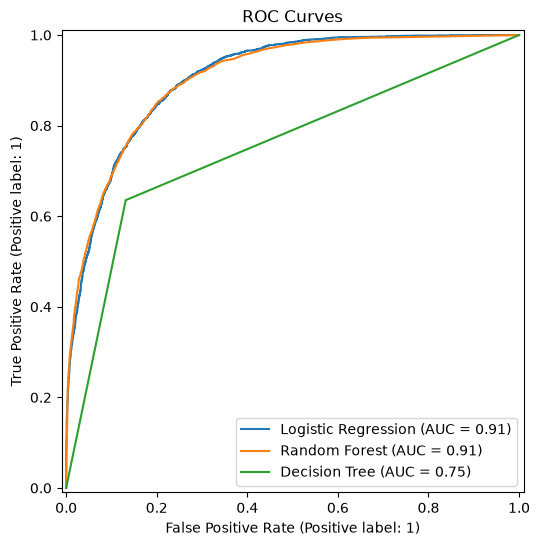

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))

for name in [
    "Logistic Regression",
    "Random Forest",
    "Decision Tree"
]:
    RocCurveDisplay.from_estimator(
        fitted[name],
        X_val,
        y_val,
        ax=ax,
        name=name
    )

plt.title("ROC Curves")

plt.savefig(
    "../reports/roc_curves.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [32]:
for name in ["Decision Tree", "Random Forest"]:
    model = fitted[name]
    
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    
    print(f"\n{name}")
    print(f"Train accuracy: {accuracy_score(y_train, train_preds):.4f}")
    print(f"Val accuracy:   {accuracy_score(y_val, val_preds):.4f}")


Decision Tree
Train accuracy: 1.0000
Val accuracy:   0.8127

Random Forest
Train accuracy: 1.0000
Val accuracy:   0.8539


In [33]:
winner = fitted["Random Forest"]

test_probs = winner.predict_proba(X_test)[:, 1]

test_preds = (test_probs >= 0.30).astype(int)

test_accuracy = accuracy_score(y_test, test_preds)
test_precision = precision_score(y_test, test_preds)
test_recall = recall_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds)
test_roc_auc = roc_auc_score(y_test, test_probs)

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1:        {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc_auc:.4f}")

Test Accuracy:  0.8302
Test Precision: 0.6119
Test Recall:    0.7938
Test F1:        0.6911
Test ROC-AUC:   0.9049


In [34]:
pd.DataFrame(results).sort_values(
    "roc_auc",
    ascending=False
).to_csv(
    "../reports/classification_comparison.csv",
    index=False
)

## Conclusion

I would deploy the Random Forest classifier with a decision threshold of
0.30 for a use case where identifying high earners is more important than
minimizing false positives.

Accuracy alone was misleading in this dataset. The majority-class baseline
achieved 76.08% accuracy while having zero recall, precision and F1 because
it predicted every person as earning <=$50K. This shows why accuracy is not
sufficient for an imbalanced classification problem.

Random Forest was selected because it provided the best F1 score (0.672)
among the main models at the default threshold, while also providing a
strong recall of 0.625. Decision Tree had slightly higher recall (0.635),
but showed substantially worse generalization and a lower F1 score.
Logistic Regression is nearly as good (ROC-AUC 0.907 vs 0.906) despite
being far simpler and fully interpretable. In a setting requiring
explainable decisions, I would consider deploying Logistic Regression
instead and losing very little predictive performance.

Threshold tuning showed that the default 0.50 threshold is not universally
optimal. At a threshold of 0.30, validation recall increased to 0.793 and
F1 increased to 0.692, at the cost of precision falling to 0.613. I would
accept this trade-off when missing a true high earner is more costly than
contacting some false positives. The opposite case would justify the opposite choice. A marketing campaign
with a fixed budget can only contact a limited number of people, so every
false positive is a wasted call. There, a threshold of 0.70 would be better:
precision rises to 0.840, though recall falls to 0.454.

Using the selected Random Forest and 0.30 threshold, the final test results
were:

- Accuracy: 0.8302
- Precision: 0.6119
- Recall: 0.7938
- F1: 0.6911
- ROC-AUC: 0.9049

The test results are very close to the validation results, suggesting that
the model's performance generalized reasonably well to the unseen test set.

The test accuracy at the selected 0.30 threshold was 0.8302, slightly
lower than the validation accuracy of 0.8347. This small drop is expected
because the model and threshold were selected using the validation set,
making its performance mildly optimistic by construction.

### Threshold decision

I selected a threshold of 0.30 because it produced the highest F1 among
the tested thresholds and substantially improved recall compared with the
default 0.50 threshold.

At 0.30, recall was 0.793 compared with 0.628 at 0.50. This means the model
identifies substantially more positive cases, while precision decreases
from 0.722 to 0.613.

The appropriate threshold ultimately depends on the relative cost of false
positives and false negatives rather than on a universal rule.

### Confusion matrix (Random Forest, threshold 0.50)

|                | Predicted ≤50K | Predicted >50K |
|----------------|---------------:|---------------:|
| **Actual ≤50K** | 6882 (TN)      | 550 (FP)       |
| **Actual >50K** | 877 (FN)       | 1460 (TP)      |

The model missed 877 high earners in the validation set. These false
negatives represent about 38% of all high earners in the validation set.
The baseline model would have missed all high earners. This demonstrates
why accuracy alone hides important classification errors.

In [36]:
pd.DataFrame(results).sort_values("roc_auc", ascending=False).to_csv(
    "../reports/classification_comparison.csv", index=False)